In [1]:
!unzip /content/sample_data/titanic.zip

Archive:  /content/sample_data/titanic.zip
  inflating: gender_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras

In [3]:
df = pd.read_csv('/content/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### Mapping Categorical Features

We need to convert categorical features like 'Sex' and 'Embarked' into numerical representations for machine learning models.

- **'Sex'**: This is a binary categorical feature ('male', 'female'), so we can use label encoding (e.g., 0 for female, 1 for male).
- **'Embarked'**: This is a nominal categorical feature ('S', 'C', 'Q'), so we will use one-hot encoding to avoid implying any ordinal relationship.

In [6]:
# Map 'Sex' column to numerical values
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1}).astype(int)

# One-hot encode 'Embarked' column
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked', drop_first=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


In [7]:
df['Age'].value_counts()

,count
Age,
24.00,30
22.00,27
18.00,26
28.00,25
30.00,25
...,...
24.50,1
0.67,1
0.42,1


In [8]:
df['Age'].unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

### Feature Distribution Visualizations

We will now visualize the distribution of each feature to understand their characteristics, identify potential outliers, and assess their impact on the target variable ('Survived').

#### Numerical Features Distribution (Histograms)

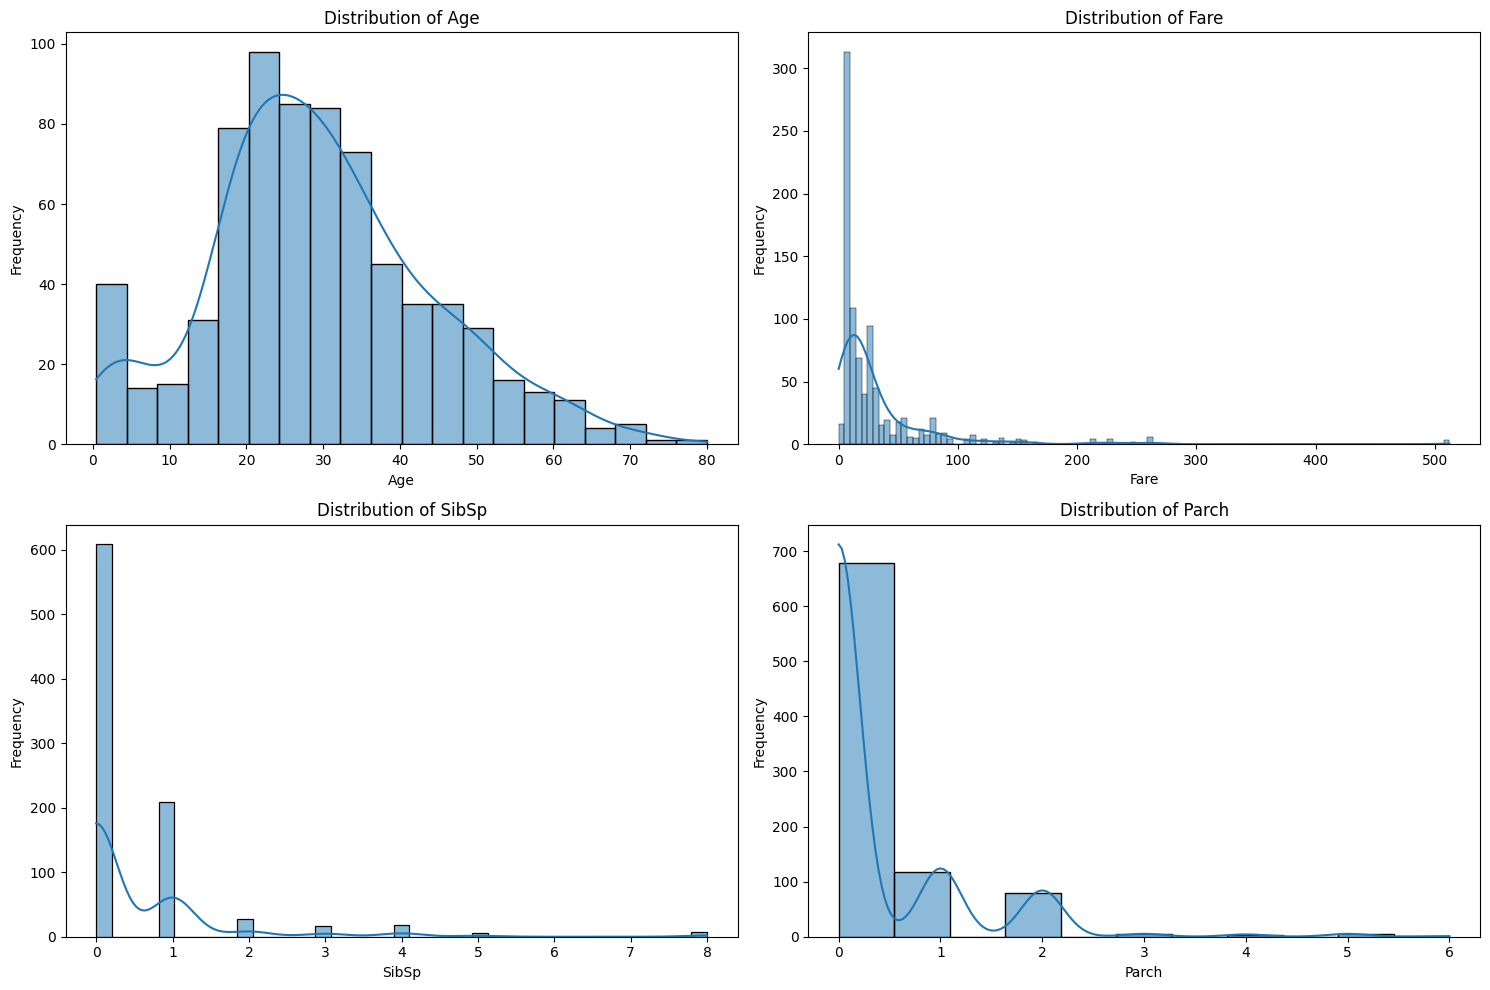

In [9]:
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Categorical Features Distribution (Count Plots)

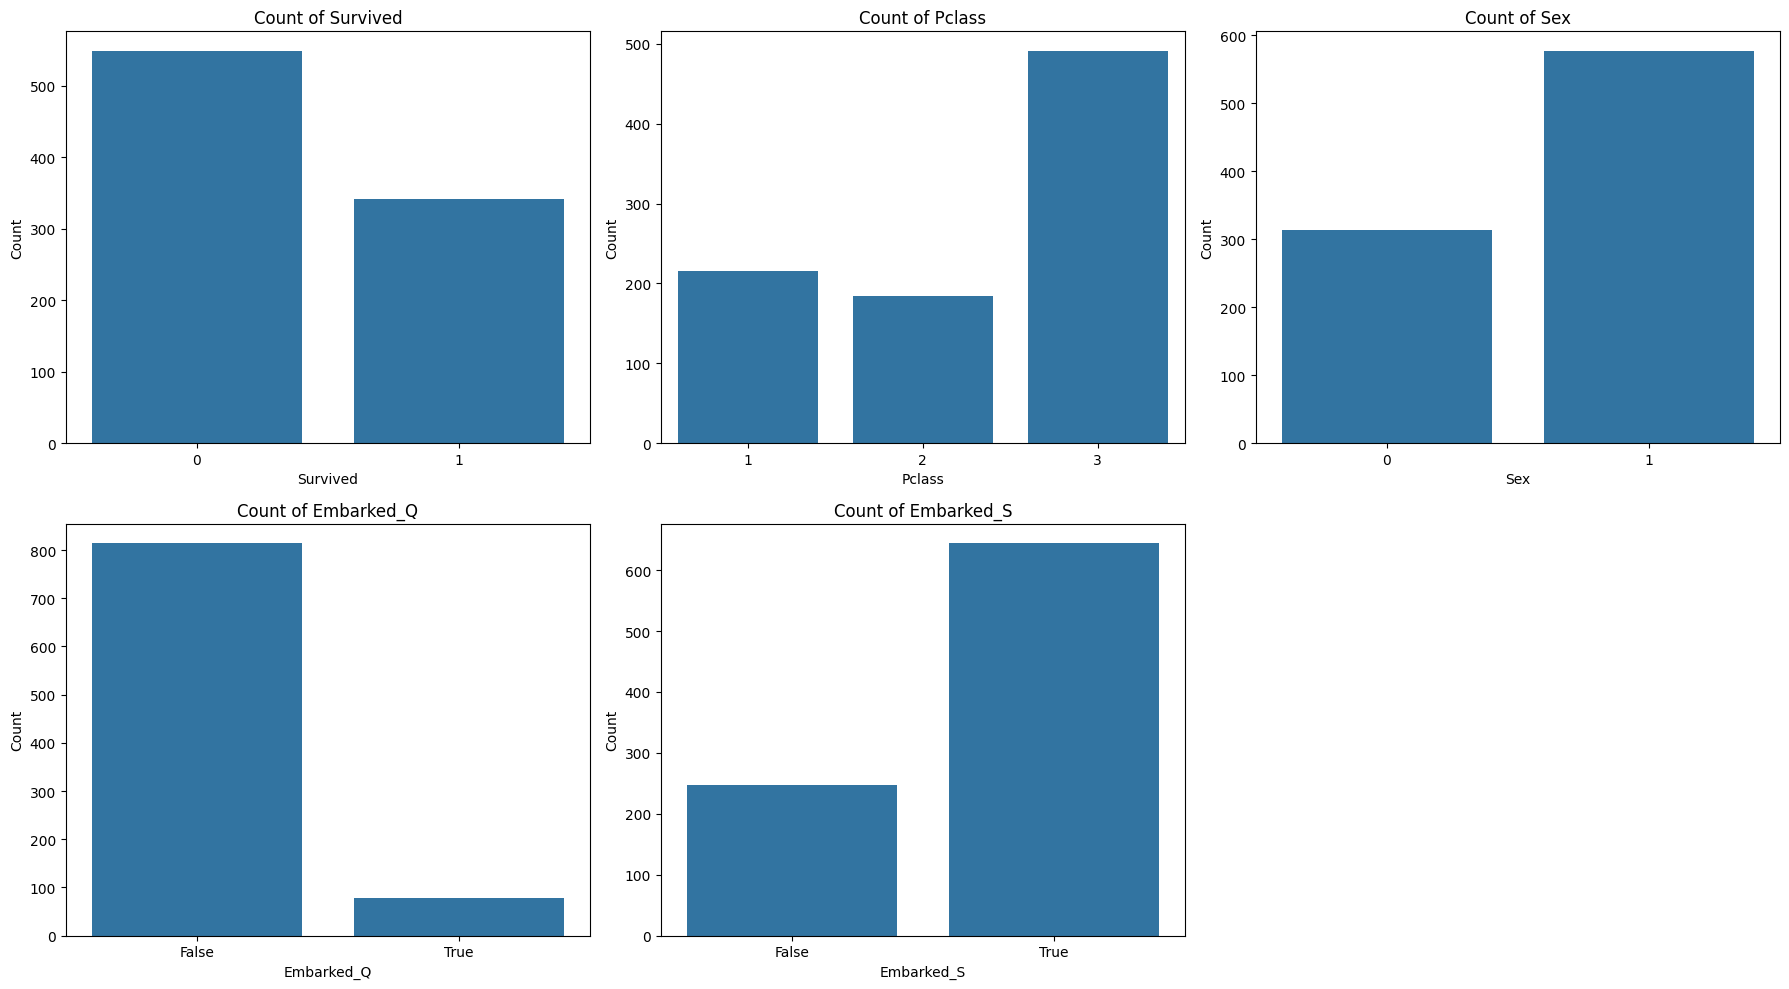

In [13]:
categorical_cols = ['Survived', 'Pclass', 'Sex', 'Embarked_Q', 'Embarked_S']

plt.figure(figsize=(18, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i) # Adjusted subplot grid for 5 plots
    sns.countplot(x=df[col])
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Imputing Missing Values in 'Age' Column

From the previous visualizations, we observed missing values in the 'Age' column. A common strategy for numerical features with missing data is to impute them with a central tendency measure, such as the median. Using the median is robust to outliers, making it a suitable choice here.

In [14]:
print(f"Missing values in 'Age' before imputation: {df['Age'].isnull().sum()}")

# Calculate the median age
median_age = df['Age'].median()

# Impute missing 'Age' values with the median
df['Age'].fillna(median_age, inplace=True)

print(f"Missing values in 'Age' after imputation: {df['Age'].isnull().sum()}")
df.head()

Missing values in 'Age' before imputation: 177
Missing values in 'Age' after imputation: 0


/tmp/ipykernel_2506/805570756.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age, inplace=True)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


### Converting One-Hot Encoded 'Embarked' Columns to Integers

Since 'Embarked' was one-hot encoded into 'Embarked_Q' and 'Embarked_S' columns, which are currently boolean, we need to convert these to integer type (0 or 1) to be consistent with other numerical features and for use in machine learning models.

In [15]:
df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,0,1
3,1,1,0,35.0,1,0,53.1000,0,1
4,0,3,1,35.0,0,0,8.0500,0,1


### Re-mapping 'Embarked' into a Single Column

Although one-hot encoding is suitable for machine learning, sometimes a single ordinal column is preferred if there's an implicit order or simply for reducing dimensionality. We will re-map the 'Embarked' information into a single column with numerical values 0, 1, and 2.

- 'C' (Cherbourg) will be mapped to 0 (since it was dropped during `get_dummies` with `drop_first=True`)
- 'Q' (Queenstown) will be mapped to 1
- 'S' (Southampton) will be mapped to 2

In [16]:
# Create a new 'Embarked' column and initialize with 0 (for 'C')
df['Embarked'] = 0

# Map 'Q' to 1
df.loc[df['Embarked_Q'] == 1, 'Embarked'] = 1

# Map 'S' to 2
df.loc[df['Embarked_S'] == 1, 'Embarked'] = 2

# Drop the one-hot encoded columns
df = df.drop(['Embarked_Q', 'Embarked_S'], axis=1)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [17]:
df['Embarked'].value_counts()

,count
Embarked,
2,644
0,170
1,77


### Splitting Data into Training and Testing Sets

Before building a predictive model, it's crucial to split the dataset into training and testing sets. The training set will be used to train our model, and the testing set will be used to evaluate its performance on unseen data. This helps in assessing the model's generalization capability and preventing overfitting.

We will define `Survived` as the target variable (y) and all other columns as features (X).

In [18]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data into training and testing sets
# Using a test_size of 0.2 (20% for testing) and a random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (712, 7)
X_test shape: (179, 7)
y_train shape: (712,)
y_test shape: (179,)


### Build a Multi-Layer Perceptron (MLP) Model

Now that the data is preprocessed and split, we can build a simple Multi-Layer Perceptron (MLP) model using Keras. This model will consist of:

1.  **Input Layer**: The number of input features (columns in `X_train`).
2.  **Two Hidden Layers**: Dense layers with ReLU activation functions to learn complex patterns.
3.  **Output Layer**: A Dense layer with a sigmoid activation function for binary classification (predicting 'Survived' or not).

We will compile the model using the `adam` optimizer and `binary_crossentropy` loss function, as this is a binary classification task.

In [41]:
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping
from keras.regularizers import l2

# Initialize the ANN
classifier = Sequential()

# Add the input layer and the first hidden layer with L2 regularization
classifier.add(Dense(units=6, kernel_initializer='he_uniform', activation='relu', input_dim=X_train.shape[1], kernel_regularizer=l2(0.01)))

# Add the second hidden layer with L2 regularization
classifier.add(Dense(units=4, kernel_initializer='he_uniform', activation='relu', kernel_regularizer=l2(0.01)))

# Add the third hidden layer (if uncommented, it should also have regularization)
#classifier.add(Dense(units=2, kernel_initializer='he_uniform', activation='relu', kernel_regularizer=l2(0.01)))

# Add the output layer
classifier.add(Dense(units=1, kernel_initializer='glorot_uniform', activation='sigmoid'))

# Compile the ANN
classifier.compile(optimizer='Adamax', loss='binary_crossentropy', metrics=['accuracy'])

classifier.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 6)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

### Train the MLP Model

We will now train the `classifier` model using the `fit` method. During training, the model will learn to map the input features (`X_train`) to the target variable (`y_train`). We'll monitor the loss and accuracy on a validation set to ensure the model is learning effectively and to detect any signs of overfitting.

In [42]:
# Define EarlyStopping callback
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10, restore_best_weights=True)

# Fit the ANN to the training set
history = classifier.fit(X_train, y_train, batch_size=20, epochs=100, validation_split=0.2, verbose=1, callbacks=[early_stop])

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6169 - loss: 10.5511 - val_accuracy: 0.6503 - val_loss: 7.8538
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6169 - loss: 9.6571 - val_accuracy: 0.6503 - val_loss: 7.2006
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6169 - loss: 8.8640 - val_accuracy: 0.6503 - val_loss: 6.6180
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6169 - loss: 8.1397 - val_accuracy: 0.6503 - val_loss: 6.0367
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6169 - loss: 7.4271 - val_accuracy: 0.6503 - val_loss: 5.5210
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6169 - loss: 6.7910 - val_accuracy: 0.6503 - val_loss: 4.9834
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6169 - loss: 6.1405 - val_accuracy: 0.6503 - val_loss: 4.4965
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6169 - loss: 5.5302 - val_accuracy: 0.6503 -

### Evaluate Model Performance

After training, it's crucial to evaluate the model's performance on both the training and test sets. This helps us understand if the model has learned effectively and how well it generalizes to unseen data. We will use several metrics:

*   **Accuracy**: The proportion of correctly classified instances.
*   **Classification Report**: Provides precision, recall, and F1-score for each class.
*   **Confusion Matrix**: A table showing the number of true positives, true negatives, false positives, and false negatives.

In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the training set
y_pred_train_prob = classifier.predict(X_train)
y_pred_train = (y_pred_train_prob > 0.5).astype(int)

# Make predictions on the test set
y_pred_test_prob = classifier.predict(X_test)
y_pred_test = (y_pred_test_prob > 0.5).astype(int)

# Evaluate training set performance
print("\n--- Training Set Evaluation ---")
print(f"Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print("Classification Report:")
print(classification_report(y_train, y_pred_train))

# Evaluate test set performance
print("\n--- Test Set Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_test))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

--- Training Set Evaluation ---
Accuracy: 0.7683
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.77      0.81       444
           1       0.67      0.76      0.71       268

    accuracy                           0.77       712
   macro avg       0.76      0.77      0.76       712
weighted avg       0.78      0.77      0.77       712


--- Test Set Evaluation ---
Accuracy: 0.7765
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       105
           1       0.72      0.76      0.74        74

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



### Visualize Confusion Matrix

The confusion matrix provides a detailed breakdown of correct and incorrect predictions for each class. We will visualize it using a heatmap for better readability.

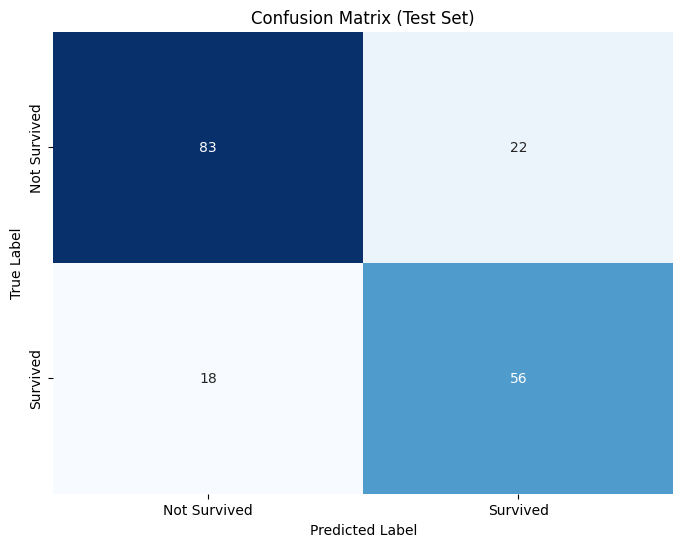

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix for the test set
cm = confusion_matrix(y_test, y_pred_test)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')
plt.show()